In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Data Collection and Preprocessing.

In [3]:
# Loading CSV data to pandas dataframe
gold_data = pd.read_csv('C:\Data Analytics Projects\Gold Price Prediction Project\gld_price_data.csv')

In [4]:
# print first 5 rows in dataframe.
gold_data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [5]:
# print last 5 rows in dataframe.
gold_data.tail()

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [6]:
# Number of rows and Columns
gold_data.shape

(2290, 6)

In [7]:
# Getting more information about data.
gold_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [8]:
# Convert Date column to datetime formate from Object.
gold_data['Date'] = pd.to_datetime(gold_data['Date'])

In [9]:
# Checking the number of missing values in each column of the daraframe.
gold_data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [10]:
# Getting the statistical measure of the data.
gold_data.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371008,1654.315776,122.732875,31.842221,20.084997,1.283653
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547


Correlation :
1. Positive Correlation.
2. Negative Correlation.

In [11]:
correlation = gold_data.corr()

<Axes: >

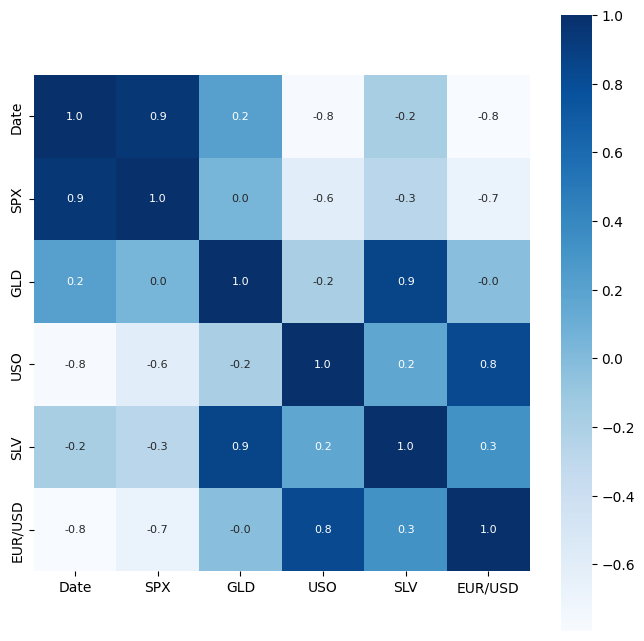

In [12]:
# Constructing the heatmap to understand the correlation.
plt.figure(figsize=(8,8))
sns.heatmap(correlation, cbar=True, square=True,fmt='.1f', annot=True, annot_kws={'size':8},cmap='Blues')

In [13]:
# Correlation value of GOLD.
print(correlation['GLD'])

Date       0.209118
SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


C:\Users\Admin\AppData\Local\Temp\ipykernel_7472\2317285188.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(gold_data['GLD'], color='green')


<Axes: xlabel='GLD', ylabel='Density'>

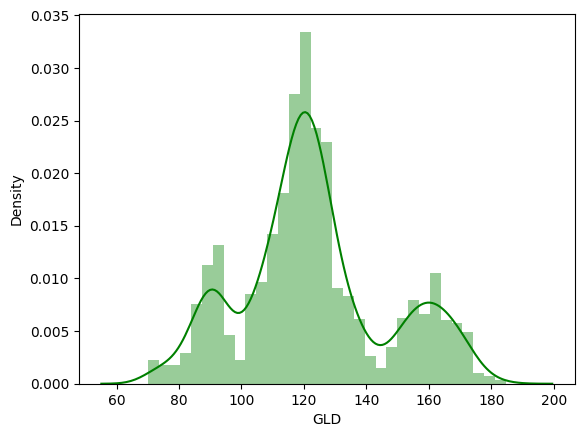

In [14]:
# Distribution of GOLd price.
sns.distplot(gold_data['GLD'], color='green')

Splitting the Features and Targets

In [15]:
X = gold_data.drop(['GLD','Date'],axis=1)
Y = gold_data['GLD']

In [16]:
X

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.1800,1.471692
1,1447.160034,78.370003,15.2850,1.474491
2,1411.630005,77.309998,15.1670,1.475492
3,1416.180054,75.500000,15.0530,1.468299
4,1390.189941,76.059998,15.5900,1.557099
...,...,...,...,...
2285,2671.919922,14.060000,15.5100,1.186789
2286,2697.790039,14.370000,15.5300,1.184722
2287,2723.070068,14.410000,15.7400,1.191753
2288,2730.129883,14.380000,15.5600,1.193118


In [17]:
Y

0        84.860001
1        85.570000
2        85.129997
3        84.769997
4        86.779999
           ...    
2285    124.589996
2286    124.330002
2287    125.180000
2288    124.489998
2289    122.543800
Name: GLD, Length: 2290, dtype: float64

Splitting into Training And Testing Data.

In [18]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2, random_state=2)

Model Trainning : 
Random Forest Regressor.

In [19]:
regressor = RandomForestRegressor(n_estimators = 100)

In [20]:
regressor.fit(X_train,Y_train)

RandomForestRegressor()

Model Evaluation.

In [21]:
# Prediction on test Data.
test_data_prediction = regressor.predict(X_test)

In [22]:
print(test_data_prediction)

[168.55889924  82.37509976 115.85349998 127.70600051 120.9827012
 154.79589792 150.69519785 126.16350059 117.52079893 125.83560095
 116.79880105 171.63080046 142.01179873 167.84709848 115.14429993
 117.84910043 138.92880311 170.3081008  159.08160272 159.83189902
 155.19190086 125.21880019 176.03369991 156.94300371 125.19050047
  94.05179989  77.4427003  120.87249994 119.10309941 167.50100007
  88.32070022 125.27719965  91.22290094 117.8295006  121.11059896
 136.41580128 115.35470123 115.21640079 148.25299941 107.05780115
 104.3719024   87.28439797 126.46070052 117.90879973 155.47129903
 119.63709998 108.37360027 108.15409853  93.10220062 127.08129776
  74.8064005  113.7352995  121.38759981 111.13259939 119.08969895
 120.84929975 159.5977996  166.07150097 146.73479692  86.21599898
  94.27140028  86.79269897  90.74630009 119.09040057 126.4553001
 127.47989967 170.94909984 122.18199936 117.21819889  98.31850023
 167.87660112 142.62959755 131.94330285 121.23790212 121.15659951
 119.7795005

In [23]:
# R squared error
error_score = metrics.r2_score(Y_test,test_data_prediction)
print(error_score)

0.9888581189926632


In [24]:
Y_test = list(Y_test)

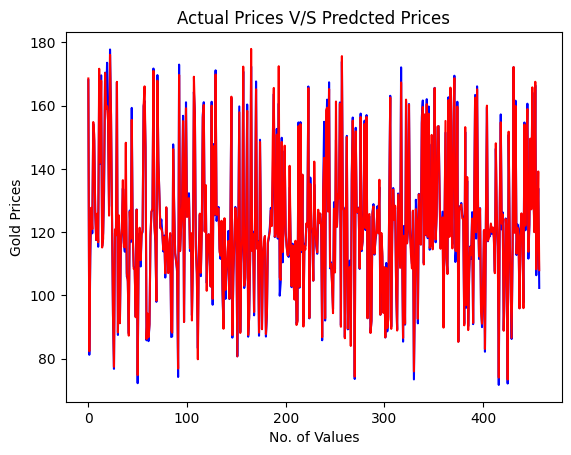

In [26]:
plt.plot(Y_test, color='blue', label='Actual Values')
plt.plot(test_data_prediction, color='red', label='Predicted Values')
plt.xlabel("No. of Values")
plt.ylabel("Gold Prices")
plt.title("Actual Prices V/S Predcted Prices")
plt.show()